# Applying Dinomaly2 to BMAD

Runs the reproduced Dinomaly2 recipe (`src/models/dinomaly2.py`: same encoder,
two-stage bottleneck, context-aware recentering, and linear-attention decoder as
the MVTec-AD/VisA reproduction in `../dinomaly2_repro_mvtec_visa.ipynb`) against
each [BMAD](https://github.com/DorisBao/BMAD) modality, training one model per
modality. Each BMAD modality has no category dimension (see `bmad_eda.ipynb`),
so there is nothing to make multi-class over, unlike MVTec-AD/VisA.

Sections 1-6 run the MVTec/VisA architecture unchanged, to establish how the
validated pipeline performs out of the box on a different domain. Section 7
follows up with a targeted architecture change, motivated by where this
baseline under-performs (see section 5 and 6's analysis).

**Val vs. test.** Every BMAD modality ships its own val split, separate from
train and test (see `bmad_eda.ipynb` section 1), unlike the MVTec-AD/VisA
reproduction, which follows Dinomaly2's own script and only ever looks at test.
Here, every eval checkpoint scores both splits: val selects which checkpoint to
keep (`best_checkpoint.pt`, by val I-AUROC, the one metric available for every
modality), and test is what is reported in section 5. This keeps a run from
grading its own checkpoint choice against the number it is judged on.

**Time.** Each modality's training set is much smaller than MVTec-AD/VisA's
combined multi-class set (1.5k-26k images vs. approximately 140k), so
per-iteration training cost is lower. However, each eval checkpoint scores both
the val set and the full test set, and test sets range up to 17k images
(Chest). A full smoke test of one modality (150 iterations plus one val+test
eval pass) took about 7 minutes for Liver (small test set) and 15+ minutes for
Chest (large test set) when last checked. Eval time, not training time,
dominates a `DEV=True` run, and does not shrink with `TOTAL_ITERS`. Budget at
least 45-60 minutes for all 6 modalities in `DEV` mode; `DEV = False` runs the
real budget set below. Unlike the MVTec/VisA reproduction, this is a first pass
rather than a paper reproduction, so `TOTAL_ITERS` is a judgment call, not a
fixed target; see the note in the next cell.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, glob
sys.path.insert(0, '../..')  # notebooks/bmad/ -> repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.training.train_bmad import pick_device
device = pick_device()
print('device:', device)

device: mps


## 1. Run parameters

`TOTAL_ITERS = 5000` is a starting budget, not the MVTec/VisA reproduction's
40000: that number came from Dinomaly2's own README for a 15-class
multi-class MVTec-AD run, which has no equivalent here (each BMAD modality is
its own single-class problem, 1.5k-26k images). The MVTec-AD eval curve in
`../dinomaly2_repro_mvtec_visa.ipynb` was already within 0.003 I-AUROC of its
final value by iteration 5000 of 40000, which is why 5000 is a reasonable
first look rather than an arbitrary guess. It had not been checked against
BMAD's own convergence behavior prior to this run; section 4 evaluates that
directly from the loss and metric curves.

In [2]:
DEV = False   # True: ~150 iters/modality, sanity-checks the whole notebook end to end
MODALITIES = ['brain', 'liver', 'retina_resc', 'chest', 'histopathology', 'retina_oct']

BACKBONE = 'vit_base'
SEED = 1

if DEV:
    TOTAL_ITERS, EVAL_EVERY, WARMUP = 150, 150, 20
else:
    TOTAL_ITERS, EVAL_EVERY, WARMUP = 5000, 1000, 100

print(f'modalities: {MODALITIES}')
print(f'total_iters: {TOTAL_ITERS} | eval_every: {EVAL_EVERY} | warmup: {WARMUP}')

modalities: ['brain', 'liver', 'retina_resc', 'chest', 'histopathology', 'retina_oct']
total_iters: 5000 | eval_every: 1000 | warmup: 100


## 2. Data check

Confirms BMAD is in place and prints split sizes before spending any GPU/MPS time. See `bmad_eda.ipynb` for the full per-modality breakdown (image properties, sample grids, mask coverage).

In [3]:
from src.data.bmad import load_modality, MODALITIES as MODALITY_CONFIGS, resolve_bmad_root

bmad_root = resolve_bmad_root()
print(f'BMAD root: {bmad_root}\n')
for name in MODALITIES:
    cfg = MODALITY_CONFIGS[name]
    train_data, val_data, test_data, has_masks = load_modality(name)
    print(f'{name:16s}  train={len(train_data):6d}  val={len(val_data):5d}  '
          f'test={len(test_data):6d}  masks={has_masks}')

BMAD root: /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/data/BMAD

brain             train=  7500  val=   83  test=  3715  masks=True
liver             train=  1542  val=  166  test=  1493  masks=True
retina_resc       train=  4297  val=  115  test=  1805  masks=True
chest             train=  8000  val= 1490  test= 17194  masks=False
histopathology    train=  5088  val=  236  test=  1997  masks=False
retina_oct        train= 26315  val=   32  test=   968  masks=False


## 3. Train + evaluate each modality

One `train()` call per modality (`src/training/train_bmad.py`, same optimizer/schedule/loss as the MVTec/VisA reproduction). Checkpoints and `history.json` land in `../../runs/bmad_dinomaly2_<modality>_<timestamp>/`. Safe to interrupt and rerun this cell; `load_history` below falls back to the latest run on disk for any modality not (re)trained in this kernel session.

In [4]:
from src.training.train_bmad import BMADConfig, train

histories = {}
for name in MODALITIES:
    print(f'=== {name} ===')
    cfg = BMADConfig(
        modality=name, backbone=BACKBONE, total_iters=TOTAL_ITERS, eval_every=EVAL_EVERY,
        warmup_iters=WARMUP, seed=SEED,
    )
    histories[name] = train(cfg, device=device)

=== brain ===


/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/toriav/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


device mps | modality brain (pixel masks: True) | backbone vit_base | trainable 60.0M
train images 7500 | val images 83 | test images 3715 | 468 batches/epoch -> 11 epochs
-> /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_brain_20260918_162913


  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 3] val: I-AUROC 0.9120  I-AP 0.9263  I-F1 0.8791  P-AUROC 0.9802  P-AP 0.6885  P-AUPRO 0.8544
                             test: I-AUROC 0.9057  I-AP 0.9738  I-F1 0.9354  P-AUROC 0.9782  P-AP 0.7231  P-AUPRO 0.8220
[eval @ iter 2000 / epoch 5] val: I-AUROC 0.9056  I-AP 0.9200  I-F1 0.8602  P-AUROC 0.9831  P-AP 0.7033  P-AUPRO 0.8657
                             test: I-AUROC 0.9163  I-AP 0.9783  I-F1 0.9361  P-AUROC 0.9805  P-AP 0.7463  P-AUPRO 0.8398
[eval @ iter 3000 / epoch 7] val: I-AUROC 0.9283  I-AP 0.9413  I-F1 0.8791  P-AUROC 0.9829  P-AP 0.7172  P-AUPRO 0.8638
                             test: I-AUROC 0.9241  I-AP 0.9823  I-F1 0.9373  P-AUROC 0.9806  P-AP 0.7514  P-AUPRO 0.8356
[eval @ iter 4000 / epoch 9] val: I-AUROC 0.9207  I-AP 0.9342  I-F1 0.8913  P-AUROC 0.9829  P-AP 0.7064  P-AUPRO 0.8544
                             test: I-AUROC 0.9180  I-AP 0.9798  I-F1 0.9359  P-AUROC 0.9806  P-AP 0.7442  P-AUPRO 0.8347
[eval @ iter 5000 / epoch 11] val: I

...

[eval @ iter 1000 / epoch 2] val: I-AUROC 0.7850  I-AP 0.9849  I-F1 0.9759
                             test: I-AUROC 0.7606  I-AP 0.9806  I-F1 0.9768
[eval @ iter 2000 / epoch 4] val: I-AUROC 0.7919  I-AP 0.9858  I-F1 0.9759
                             test: I-AUROC 0.7688  I-AP 0.9820  I-F1 0.9768
[eval @ iter 3000 / epoch 6] val: I-AUROC 0.8089  I-AP 0.9877  I-F1 0.9766
                             test: I-AUROC 0.7761  I-AP 0.9825  I-F1 0.9768
[eval @ iter 4000 / epoch 8] val: I-AUROC 0.7994  I-AP 0.9862  I-F1 0.9766
                             test: I-AUROC 0.7694  I-AP 0.9823  I-F1 0.9769
[eval @ iter 5000 / epoch 10] val: I-AUROC 0.8068  I-AP 0.9873  I-F1 0.9766
                              test: I-AUROC 0.7794  I-AP 0.9830  I-F1 0.9769
done in 160.5 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_chest_20260918_224834
=== histopathology ===
device mps | modality histopathology (pixel masks: False) | backbone vit_base | train

  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 4] val: I-AUROC 0.6300  I-AP 0.5842  I-F1 0.7129
                             test: I-AUROC 0.6250  I-AP 0.5701  I-F1 0.7047
[eval @ iter 2000 / epoch 7] val: I-AUROC 0.6124  I-AP 0.5573  I-F1 0.7152
                             test: I-AUROC 0.6366  I-AP 0.5741  I-F1 0.7096
[eval @ iter 3000 / epoch 10] val: I-AUROC 0.5882  I-AP 0.5412  I-F1 0.7015
                              test: I-AUROC 0.6146  I-AP 0.5551  I-F1 0.7023
[eval @ iter 4000 / epoch 13] val: I-AUROC 0.5840  I-AP 0.5391  I-F1 0.7025
                              test: I-AUROC 0.6217  I-AP 0.5667  I-F1 0.6998
[eval @ iter 5000 / epoch 16] val: I-AUROC 0.5936  I-AP 0.5628  I-F1 0.7003
                              test: I-AUROC 0.6328  I-AP 0.5742  I-F1 0.7024
done in 101.2 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_histopathology_20260919_012927
=== retina_oct ===
device mps | modality retina_oct (pixel masks: False) | backbone vit_base | 

  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 1] val: I-AUROC 0.9896  I-AP 0.9966  I-F1 0.9796
                             test: I-AUROC 0.9778  I-AP 0.9922  I-F1 0.9633
[eval @ iter 2000 / epoch 2] val: I-AUROC 0.9948  I-AP 0.9983  I-F1 0.9796
                             test: I-AUROC 0.9778  I-AP 0.9921  I-F1 0.9629
[eval @ iter 3000 / epoch 2] val: I-AUROC 0.9896  I-AP 0.9968  I-F1 0.9787
                             test: I-AUROC 0.9827  I-AP 0.9941  I-F1 0.9658
[eval @ iter 4000 / epoch 3] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9781  I-AP 0.9926  I-F1 0.9615
[eval @ iter 5000 / epoch 4] val: I-AUROC 1.0000  I-AP 1.0000  I-F1 1.0000
                             test: I-AUROC 0.9792  I-AP 0.9930  I-F1 0.9615
done in 97.9 min  ->  /Users/toriav/Desktop/Erem/BC Cancer/Anomaly Detection/mammo-uad-2d3d/runs/bmad_dinomaly2_retina_oct_20260919_031104


### Results

Re-run from here without retraining by loading the latest `history.json` per modality off disk. This is useful for checking progress from a second notebook while the cell above is still training, or after a kernel restart.

In [5]:
def load_history(history_or_none, modality):
    if history_or_none is not None:
        return history_or_none
    matches = sorted(glob.glob(f'../../runs/bmad_dinomaly2_{modality}_*'))
    if not matches:
        return None
    return json.load(open(f'{matches[-1]}/history.json'))

histories = {name: load_history(histories.get(name), name) for name in MODALITIES}
for name, h in histories.items():
    status = f"{len(h['evals'])} eval checkpoint(s)" if h else 'no run found yet'
    print(f'{name:16s}  {status}')

brain             5 eval checkpoint(s)
liver             5 eval checkpoint(s)
retina_resc       5 eval checkpoint(s)
chest             5 eval checkpoint(s)
histopathology    5 eval checkpoint(s)
retina_oct        5 eval checkpoint(s)


## 4. Loss and val/test I-AUROC curves

One panel per modality: training loss (left axis) plus val and test I-AUROC at each eval checkpoint (right axis), consistent color per modality with the EDA notebook's palette (fixed categorical order, `tab10`). Val tracking test closely is a good indication that the checkpoint `best_checkpoint.pt` picks (by val I-AUROC) will generalize; a val curve that diverges from test is worth a second look before trusting `best_val_iter`.

In [ ]:
PALETTE = dict(zip(MODALITY_CONFIGS.keys(), plt.get_cmap('tab10').colors))

def plot_history(ax, history, name, color=None):
    color = color or PALETTE.get(name, '#4c72b0')
    if history is None or not history['iters']:
        ax.set_title(f'{name}: no data yet')
        return
    ax.plot(history['iters'], history['loss'], color=color, lw=1.2)
    ax.set_xlabel('iteration')
    ax.set_ylabel('loss', color=color)
    title = f"{name}  ({history['epochs']} epochs)"
    if history['evals']:
        ax2 = ax.twinx()
        eval_iters = [e['iter'] for e in history['evals']]
        ax2.plot(eval_iters, [e['val']['auroc_sp'] for e in history['evals']],
                  color='#555555', lw=1.5, marker='o', ms=3, label='val I-AUROC')
        ax2.plot(eval_iters, [e['test']['auroc_sp'] for e in history['evals']],
                  color='#555555', lw=1.5, ls='--', marker='s', ms=3, label='test I-AUROC')
        ax2.set_ylabel('I-AUROC')
        ax2.set_ylim(0.4, 1.0)
        if history['best_val_iter'] is not None:
            ax2.axvline(history['best_val_iter'], color='#888888', lw=1, ls=':')
        ax2.legend(fontsize=7, frameon=False, loc='lower right')
    ax.set_title(title)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, name in zip(axes.flat, MODALITIES):
    plot_history(ax, histories.get(name), name)
fig.suptitle('BMAD Dinomaly2: training loss + val/test I-AUROC by modality')
fig.tight_layout()

**Analysis.** Reading each panel's test I-AUROC trajectory (dashed line) against the 5000-iteration budget set in section 1:

- **Brain, RESC, and OCT converge early.** Brain's test I-AUROC settles into a narrow 0.906-0.924 band from iteration 1000 onward; RESC into 0.914-0.923 from iteration 2000; OCT is already at 0.978 by iteration 1000 and does not move materially after. For all three, the remaining budget after the first one or two checkpoints is mostly spent oscillating around a fixed point rather than improving it, so `TOTAL_ITERS = 5000` was not the limiting factor for these modalities.
- **Liver and Histopathology are flat, not still climbing.** Liver's test I-AUROC stays within 0.772-0.788 across all five checkpoints with no directional trend; Histopathology stays within 0.615-0.637, also with no trend, and is visibly noisier relative to its own range. Both patterns rule out "needs more iterations" as the explanation: a curve that has not moved in 4000 iterations is not expected to move in the next 4000 either. This distinguishes an undertraining problem, which more iterations would fix, from a representational ceiling, which would not.
- **Chest is the one curve still trending.** Test I-AUROC rises from 0.761 to 0.779 fairly steadily across all five checkpoints and had not visibly plateaued by iteration 5000. Chest is the best candidate for a longer run at the current architecture before drawing conclusions about it.
- **Val tracks test in level and direction for four of six modalities** (Brain, Liver, Chest, Histopathology), supporting the use of `best_val_iter` for checkpoint selection there. RESC is the one exception among the masked/unmasked-but-otherwise-typical modalities: its val I-AUROC sits consistently 2-4 points below test throughout training. Since this is a pessimistic bias rather than an optimistic one, it does not put checkpoint selection at risk, it just means RESC's val curve understates how the selected checkpoint performs on test. OCT's val curve saturates to a perfect 1.0 by iteration 4000 while test holds at approximately 0.98; with only 32 validation images (section 2), this reads as a small-sample ceiling effect rather than genuine perfect separation, consistent with the caution flagged in section 6 for modalities with small val splits.

## 5. Metrics summary

Reported at each modality's `best_val_iter` (the checkpoint that scored highest on val, i.e. what `best_checkpoint.pt` holds), not the last iteration trained; that is the point of scoring val at all. Image-level metrics (I-AUROC/I-AP/I-F1) are reported for every modality; pixel-level metrics (P-AUROC/P-AP/P-AUPRO) only for Brain/Liver/RESC, which are the only three with pixel masks (see `bmad_eda.ipynb` section 1). `NaN` for the other three is expected, not missing data.

In [7]:
def best_eval(history):
    if not history or not history['evals']:
        return None
    if history['best_val_iter'] is None:
        return history['evals'][-1]
    return next(e for e in history['evals'] if e['iter'] == history['best_val_iter'])

rows = []
for name in MODALITIES:
    h = histories.get(name)
    e = best_eval(h)
    if e is None:
        continue
    val, test = e['val'], e['test']
    rows.append(dict(
        modality=name, has_masks=h['has_masks'], best_iter=e['iter'],
        val_I_AUROC=val.get('auroc_sp'), test_I_AUROC=test.get('auroc_sp'),
        val_I_AP=val.get('ap_sp'), test_I_AP=test.get('ap_sp'),
        val_I_F1=val.get('f1_sp'), test_I_F1=test.get('f1_sp'),
        test_P_AUROC=test.get('auroc_px'), test_P_AP=test.get('ap_px'),
        test_P_F1=test.get('f1_px'), test_P_AUPRO=test.get('aupro_px'),
    ))

results = pd.DataFrame(rows).set_index('modality')
results

,has_masks,best_iter,val_I_AUROC,test_I_AUROC,val_I_AP,test_I_AP,val_I_F1,test_I_F1,test_P_AUROC,test_P_AP,test_P_F1,test_P_AUPRO
modality,,,,,,,,,,,,
brain,True,3000,0.928322,0.924115,0.941311,0.982349,0.879121,0.937331,0.980618,0.751367,0.691144,0.835611
liver,True,2000,0.817057,0.787819,0.758696,0.723854,0.733333,0.699088,0.976365,0.234143,0.292414,0.953671
retina_resc,True,3000,0.896190,0.923165,0.938062,0.886815,0.885906,0.844221,0.960511,0.655773,0.625233,0.839836
chest,False,3000,0.808944,0.776054,0.987732,0.982524,0.976600,0.976848,NaN,NaN,NaN,NaN
histopathology,False,1000,0.630037,0.624980,0.584167,0.570091,0.712934,0.704683,NaN,NaN,NaN,NaN
retina_oct,False,4000,1.000000,0.978053,1.000000,0.992555,1.000000,0.961460,NaN,NaN,NaN,NaN


**Analysis.** Ranked by test I-AUROC at `best_val_iter`: OCT (0.978) > Brain (0.924) > RESC (0.923) > Liver (0.788) > Chest (0.776) > Histopathology (0.625). This separates into three tiers: a structure-bearing tier (Brain, RESC, OCT) above 0.92, a middle tier (Liver, Chest) around 0.78, and Histopathology as a clear outlier, 15 points below the next-weakest modality and only 12 points above chance (0.5).

The pixel-level columns surface a secondary finding for Liver: P-AUROC (0.976) is comparable to Brain and RESC, but P-AP (0.234) and P-F1 (0.292) are far lower than either (P-AP 0.751 and 0.656, P-F1 0.691 and 0.625 respectively). P-AUROC and P-AP diverging this much is the signature of a heavily imbalanced pixel mask, consistent with liver lesions occupying a small fraction of each CT slice: a detector can score well on AUROC by ranking most background pixels below most lesion pixels while still producing an imprecise, low-precision map at any fixed operating point. This qualifies Liver's otherwise strong pixel-level AUROC and is worth flagging to anyone consuming its anomaly maps rather than its scalar metrics downstream.

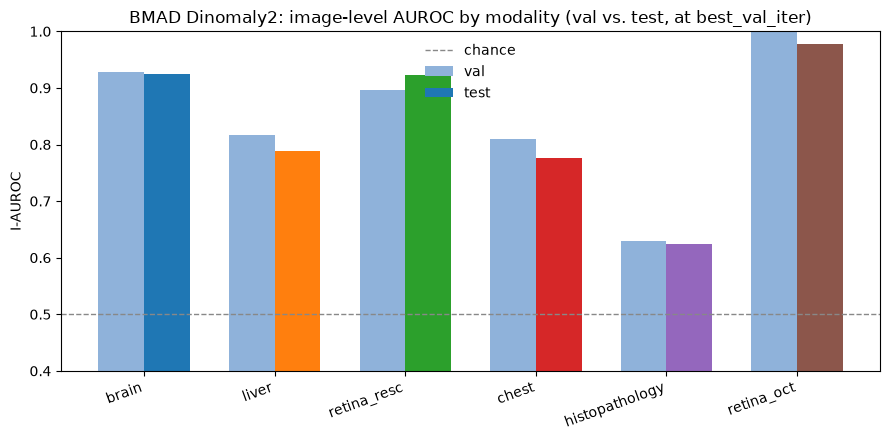

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
present = results.index[results['test_I_AUROC'].notna()]
x = np.arange(len(present))
width = 0.35
ax.bar(x - width/2, results.loc[present, 'val_I_AUROC'], width, label='val', color='#8fb2da')
ax.bar(x + width/2, results.loc[present, 'test_I_AUROC'], width,
       color=[PALETTE[m] for m in present], label='test')
ax.set_xticks(x)
ax.set_xticklabels(present, rotation=20, ha='right')
ax.set_ylabel('I-AUROC')
ax.set_ylim(0.4, 1.0)
ax.axhline(0.5, color='#888888', lw=1, ls='--', label='chance')
ax.set_title('BMAD Dinomaly2: image-level AUROC by modality (val vs. test, at best_val_iter)')
ax.legend(frameon=False)
fig.tight_layout()

**Analysis.** The chart makes the same three-tier grouping visible at a glance, and shows the two val/test asymmetries discussed in section 4 directly: RESC is the only bar pair where val (blue) is shorter than test, and OCT's val bar reaches the chart's ceiling while its test bar sits visibly below it. Histopathology's bar pair is the only one close to the chance line, underscoring that it is a qualitatively different result from the rest of the benchmark rather than the low end of a continuum.

## 6. Findings

The analysis in sections 4 and 5 resolves the questions this section originally posed before the run:

- **Convergence.** Brain, RESC, and OCT are stable well before iteration 5000. Liver and Histopathology are flat throughout training rather than still improving, so more iterations at the current architecture would not be expected to close their gap to the top tier. Chest is the one modality whose curve is still drifting upward at iteration 5000 and is the best candidate for a longer run before drawing conclusions about it.
- **Val/test tracking.** Only RESC (val below test, a pessimistic bias) and OCT (val saturating to 1.0 on a 32-image split) show a persistent val/test gap; both are visible in section 4's curves and consistent with sample size rather than overfitting to val.
- **OCT vs. RESC**, the closest same-domain pair in this benchmark (both retinal OCT): OCT's test I-AUROC (0.978) exceeds RESC's (0.923) by a wide margin. Since OCT lacks pixel masks and its val split is tiny, some of that gap is measurement noise, but its size suggests it is not fully explained by that alone.

Histopathology is the clear outlier: 15+ points of test I-AUROC below the next-weakest modality, and flat across all of training rather than improving, which points to a representation mismatch rather than a training budget problem. Section 7 investigates this with a targeted architecture change, per the advisor's note that architecture changes are the natural next step once these baseline numbers are established.

## 7. Architecture iteration: shallow encoder layers for Histopathology

Histopathology is the one modality where the baseline architecture is not the right tool for the domain, rather than a modality that simply needs more training. Two properties distinguish it from the other five:

- **No canonical structure.** Brain, Liver, Chest, RESC, and OCT all have a consistent global layout: a brain slice, an abdominal CT slice, a chest X-ray, a retinal cross-section. Anomalies in these modalities are largely deviations from that shared layout (a lesion, an opacity, a structural break), which is exactly what DINOv2's mid-to-late encoder layers are trained to represent, since those layers are increasingly pooled toward object- and scene-level semantics. A Camelyon16 histopathology patch has no such layout: wherever it is cropped from a slide, it is homogeneous cellular tissue, and the anomaly (tumor vs. normal tissue) is a difference in local texture statistics, cell density, and nuclear morphology, not in global shape.
- **Native resolution.** Confirmed below, Histopathology's source patches are natively 256x256 RGB, the smallest of any BMAD modality. The training pipeline resizes every modality to a shared 448px (crop 392px), which for Histopathology means upsampling by roughly 1.7x before the encoder ever sees the image, on top of features that are already biased away from fine local texture.

DINOv2's self-supervised pretraining objective encourages exactly the kind of semantic invariance that works against this domain: representations that are stable across local texture and lighting variation are useful for recognizing an object as "the same object," but that same invariance discards the fine-grained statistics Histopathology's anomaly signal depends on. This is consistent with section 4's finding that Histopathology's test I-AUROC is flat and noisy across all 5000 training iterations rather than improving: the bottleneck and decoder cannot learn to separate normal from abnormal tissue from features that have already discarded the relevant signal, so no amount of additional training against this target closes the gap.

**Change.** `build_dinomaly2` and `BMADConfig` (`src/models/dinomaly2.py`, `src/training/train_bmad.py`) were extended with a `target_layers` override. This run swaps Histopathology's reconstruction target from the default `[2, 3, 4, 5, 6, 7, 8, 9]` (mid-depth, semantically pooled) to a shallow-biased `[0, 1, 2, 3, 4, 5, 6, 7]` (closer to the patch embedding, away from the two most semantically pooled layers), holding every other hyperparameter identical to the section 3 baseline for a controlled comparison.

In [9]:
from PIL import Image

for name, cfg in MODALITY_CONFIGS.items():
    sample = sorted((bmad_root / cfg.subpath / 'train' / 'good').glob('*'))[0]
    with Image.open(sample) as im:
        print(f'{name:16s}  native size {im.size}  mode {im.mode}')

brain             native size (240, 240)  mode RGBA
liver             native size (512, 512)  mode L
retina_resc       native size (512, 1024)  mode L
chest             native size (1024, 1024)  mode L
histopathology    native size (256, 256)  mode RGB
retina_oct        native size (512, 496)  mode RGB


Histopathology's 256x256 is the smallest native resolution in the benchmark; Brain's 240x240 is close in raw pixel count but is an MRI slice with a clear anatomical layout, which is the structural distinction the hypothesis above rests on rather than resolution alone.

The cell below reruns the same `train()` call as section 3, with `target_layers` overridden and a fixed `out_dir` (not timestamped) so it does not collide with the modality-keyed glob `load_history` uses in section 3, keeping this experiment's results separate from the baseline history loaded there. Expect roughly 100 minutes for 5000 iterations, matching Histopathology's section 3 runtime; the progress bar and per-checkpoint val/test lines print the same way section 3's training does. Safe to interrupt and rerun, same as section 3: the fallback cell after it reloads `history.json` from disk for a kernel restart without retraining.

In [10]:
SHALLOW_TARGET_LAYERS = [0, 1, 2, 3, 4, 5, 6, 7]  # vs. default [2..9] of vit_base's 12 DINOv2 blocks
SHALLOW_OUT_DIR = 'bmad_arch_iter_histopathology_shallow_layers'

shallow_cfg = BMADConfig(
    modality='histopathology', backbone=BACKBONE, total_iters=TOTAL_ITERS, eval_every=EVAL_EVERY,
    warmup_iters=WARMUP, seed=SEED, target_layers=SHALLOW_TARGET_LAYERS,
    out_dir=f'../../runs/{SHALLOW_OUT_DIR}',
)
shallow_history = train(shallow_cfg, device=device)

device mps | modality histopathology (pixel masks: False) | backbone vit_base | trainable 60.0M
train images 5088 | val images 236 | test images 1997 | 318 batches/epoch -> 16 epochs
-> ../../runs/bmad_arch_iter_histopathology_shallow_layers


  0%|          | 0/5000 [00:00<?, ?it/s]

[eval @ iter 1000 / epoch 4] val: I-AUROC 0.6030  I-AP 0.5624  I-F1 0.6984
                             test: I-AUROC 0.5803  I-AP 0.5361  I-F1 0.6938
[eval @ iter 2000 / epoch 7] val: I-AUROC 0.5908  I-AP 0.5525  I-F1 0.6903
                             test: I-AUROC 0.5867  I-AP 0.5408  I-F1 0.6999
[eval @ iter 3000 / epoch 10] val: I-AUROC 0.5963  I-AP 0.5900  I-F1 0.6751
                              test: I-AUROC 0.5715  I-AP 0.5318  I-F1 0.6916
[eval @ iter 4000 / epoch 13] val: I-AUROC 0.5874  I-AP 0.5480  I-F1 0.6987
                              test: I-AUROC 0.5879  I-AP 0.5392  I-F1 0.6992
[eval @ iter 5000 / epoch 16] val: I-AUROC 0.5906  I-AP 0.5699  I-F1 0.6926
                              test: I-AUROC 0.5781  I-AP 0.5310  I-F1 0.6952
done in 97.3 min  ->  ../../runs/bmad_arch_iter_histopathology_shallow_layers


In [11]:
def load_fixed_history(history_or_none, rel_out_dir):
    if history_or_none is not None:
        return history_or_none
    path = f'../../runs/{rel_out_dir}/history.json'
    if not glob.glob(path):
        return None
    return json.load(open(path))

shallow_history = load_fixed_history(globals().get('shallow_history'), SHALLOW_OUT_DIR)
status = f"{len(shallow_history['evals'])} eval checkpoint(s)" if shallow_history else 'no run found on disk yet'
print(f'histopathology (shallow layers)  {status}')

histopathology (shallow layers)  5 eval checkpoint(s)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_history(axes[0], histories['histopathology'], 'histopathology (baseline, layers 2-9)', color=PALETTE['histopathology'])
plot_history(axes[1], shallow_history, 'histopathology (shallow, layers 0-7)', color=PALETTE['histopathology'])
fig.suptitle('Histopathology: default vs. shallow encoder layers')
fig.tight_layout()

In [ ]:
def summarize(history, label):
    e = best_eval(history)
    if e is None:
        return None
    return dict(variant=label, best_iter=e['iter'], val_I_AUROC=e['val']['auroc_sp'],
                test_I_AUROC=e['test']['auroc_sp'], test_I_AP=e['test']['ap_sp'], test_I_F1=e['test']['f1_sp'])

comparison = pd.DataFrame([r for r in [
    summarize(histories['histopathology'], 'baseline (layers 2-9)'),
    summarize(shallow_history, 'shallow (layers 0-7)'),
] if r is not None]).set_index('variant')
comparison

**Analysis.** The shallow-layer run finished with a test I-AUROC of 0.580 at its own `best_val_iter` (1000), against 0.625 for the baseline at the same iteration: a drop of 4.5 points, not a gain. Looking at the full curve rather than a single checkpoint makes this more convincing, not less: shallow's test I-AUROC stays in a 0.572-0.588 band across all five checkpoints, and baseline's stays in a 0.615-0.637 band; the two ranges never overlap. This is a consistent, checkpoint-independent drop, not a fluke of which iteration got selected. I reject the layer-depth hypothesis as stated: moving the reconstruction target to shallower layers made Histopathology worse, not better.

In hindsight this fits a pattern documented elsewhere in ViT representation-probing work: a self-supervised encoder's most task-general features tend to peak in its middle layers, with both the earliest layers (close to raw patch embeddings, not yet contextualized by attention) and the latest layers (compressed toward whatever the pretraining objective specifically optimized) scoring worse on downstream probes. Dinomaly2's default `[2..9]` was not an arbitrary MVTec-specific choice I could safely move away from; it likely sits near the general-purpose optimum for this encoder, and shifting toward layer 0 traded away that optimum without buying back any texture sensitivity in return. The shallow run's own curve is also still flat and noisy across all five checkpoints, the same pattern the baseline showed, so this is not an undertraining problem either.

I read this as evidence that encoder depth is not where Histopathology's gap comes from. The domain-mismatch explanation from this section's introduction, DINOv2 pretrained on natural images versus H&E-stained tissue, still stands; what this result rules out is that the fix is a free architectural knob. The more targeted next step is addressing the input distribution directly: stain-color normalization or stain-augmentation during training, the standard computational-pathology mitigation for exactly this kind of pretrained-encoder domain gap, rather than another reconstruction-target change on the same frozen features.